In [1]:
%pip install bitarray
%pip install numpy
%pip install mmh3
%pip install nltk pandas
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import nltk
nltk.download("words")

from nltk.corpus import words as nltk_words
from urllib.parse import urlparse

#basic imports
import numpy as np
import random
import time
import math

# Bloom filter dependencies
import mmh3
from bitarray import bitarray

# ML model ones
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

# Reproducibility
random.seed(42)
np.random.seed(42)

[nltk_data] Downloading package words to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [3]:
#standard bloom fliter

class BloomFilter:
    def __init__(self, n, fpr):
        self.m = int(-(n * math.log(fpr)) / (math.log(2) ** 2))
        self.k = max(1, int((self.m / n) * math.log(2)))
        self.bits = bitarray(self.m)
        self.bits.setall(0)

    def _hashes(self, item):
        for i in range(self.k):
            yield mmh3.hash(item, i) % self.m

    def insert(self, item):
        for h in self._hashes(item):
            self.bits[h] = 1

    def query(self, item):
        return all(self.bits[h] for h in self._hashes(item))

    def memory_bits(self):
        return self.m

In [4]:
#features function
def get_features_word(s):
    return np.array([
        len(s),
        sum(c.isalpha() for c in s),
        sum(c.isdigit() for c in s),
        s.count('_'),
        sum(c in 'aeiou' for c in s),
        len(set(s)),
        mmh3.hash(s) % 1000
    ])

def get_features_url(s):
    return np.array([
        len(s),
        s.count('.'),
        s.count('/'),
        s.count('?'),
        s.count('='),
        int(s.startswith("https")),
        int("www" in s),
        int("api" in s or "dev" in s),
        sum(c.isdigit() for c in s),
        mmh3.hash(s) % 1000
    ])

In [5]:
#learnt bloom

class LearnedBloomFilter:
    def __init__(self, model, scaler, threshold, backup_n, backup_fpr, feature_fn):
        self.model = model
        self.scaler = scaler
        self.threshold = threshold
        self.feature_fn = feature_fn
        self.backup_bf = BloomFilter(max(backup_n, 100), backup_fpr)

    def _prob(self, key):
        x = self.scaler.transform([self.feature_fn(key)])
        return self.model.predict_proba(x)[0][1]

    def insert(self, key):
        if self._prob(key) <= self.threshold:
            self.backup_bf.insert(key)

    def query(self, key):
        if self._prob(key) > self.threshold:
            return True
        return self.backup_bf.query(key)

    def memory_bits(self):
        bits = 0
        for clf in self.model.calibrated_classifiers_:
            base = getattr(clf, "estimator", None) or getattr(clf, "base_estimator", None)
            if base is not None:
                bits += (base.coef_.nbytes + base.intercept_.nbytes) * 8
        return bits + self.backup_bf.memory_bits()

In [6]:
# backup bloom

class SandwichedBloomFilter:
    """Pre-BF → ML model → backup BF"""
    def __init__(self, model, scaler, threshold, feature_fn, n_pre, fpr_pre, n_backup, fpr_backup):
        self.pre_bf = BloomFilter(n_pre, fpr_pre)       # front filter
        self.lbf = LearnedBloomFilter(model, scaler, threshold, n_backup, fpr_backup, feature_fn)

    def insert(self, key):
        self.pre_bf.insert(key)
        self.lbf.insert(key)

    def query(self, key):
        if not self.pre_bf.query(key):  # fast reject
            return False
        return self.lbf.query(key)      # ML decides the rest

    def memory_bits(self):
        return self.pre_bf.memory_bits() + self.lbf.memory_bits()

In [7]:
#synthetic data generator
n = 50000 
def random_string(k=10):
    return ''.join(random.choices('abcdefghijklmnopqrstuvwxyz0123456789', k=k))

def make_uniform_dataset(n):
    pos = [random_string() for _ in range(n)]
    neg = [random_string() for _ in range(n)]
    return pos, neg

In [8]:
def make_zipf_dataset(n, vocab_size=100000, s=1.2):
    vocab = [f"item_{i:06d}" for i in range(vocab_size)]
    weights = np.array([1.0/(i**s) for i in range(1, vocab_size+1)])
    weights /= weights.sum()
    pos = list(np.random.choice(vocab, size=n, replace=False, p=weights))
    neg = [random_string() for _ in range(n)]
    return pos, neg

BASE_WORDS = [
    "apple","banana","orange","grape","mango","pineapple",
    "computer","science","engineering","mathematics","physics",
    "algorithm","data","structure","network","system",
    "learning","model","training","prediction","analysis",
    "python","java","javascript","variable","function",
    "memory","process","thread","kernel","compile",
    "internet","protocol","server","client","database",
    "search","optimization","gradient","matrix","vector"
]

def make_word_dataset(n):
    pos, neg = [], []
    pos_set = set()
    for i in range(n):
        w = random.choice(BASE_WORDS)
        if random.random() < 0.3:
            w += str(random.randint(1, 999))
        pos.append(w)
        pos_set.add(w)

    attempts = 0
    while len(neg) < n and attempts < n * 10:
        base = random.choice(BASE_WORDS)
        idx = random.randint(0, len(base) - 1)
        candidate = base[:idx] + random.choice('abcdefghijklmnopqrstuvwxyz') + base[idx+1:]
        if candidate not in pos_set:
            neg.append(candidate)
        attempts += 1
    # fill remainder with random strings if mutations exhausted
    while len(neg) < n:
        neg.append(random_string(random.randint(4, 10)))
    return pos, neg

DOMAINS = [
    "github.com","google.com","youtube.com","wikipedia.org",
    "reddit.com","stackoverflow.com","amazon.com","bbc.com",
    "arxiv.org","medium.com","linkedin.com","twitter.com"
]
SUBDOMAINS = ["www","api","blog","docs","news","m","dev"]
PATHS = ["article","post","user","product","search","repo","issues"]

def make_url_dataset(n):
    pos = [
        f"https://{random.choice(SUBDOMAINS)}.{random.choice(DOMAINS)}/{random.choice(PATHS)}/{random.randint(1,99999)}"
        for _ in range(n)
    ]
    neg = [f"http://{''.join(random.choices('abcxyz123',k=8))}.fake/{random.randint(1000,9999)}"
           for _ in range(n)]
    return pos, neg


datasets_synthetic = {
    "Uniform": make_uniform_dataset(n),
    "Zipf":    make_zipf_dataset(n),
    "Words":   make_word_dataset(n),
    "URLs":    make_url_dataset(n),
}

for name, (pos, neg) in datasets_synthetic.items():
    print(f"{name:10s} -> {len(pos)} positives, {len(neg)} negatives | sample: {pos[0]}")

Uniform    -> 50000 positives, 50000 negatives | sample: xaji0y6dpb
Zipf       -> 50000 positives, 50000 negatives | sample: item_000004
Words      -> 50000 positives, 50000 negatives | sample: computer
URLs       -> 50000 positives, 50000 negatives | sample: https://www.youtube.com/issues/72529


In [9]:
# real-world word dataset + real URL loader

def load_real_word_dataset(n_pos=50000, n_neg=50000, seed=42):
    rng = random.Random(seed)

    vocab = sorted({
        w.lower()
        for w in nltk_words.words()
        if w.isalpha() and 3 <= len(w) <= 15
    })

    pos = rng.sample(vocab, min(n_pos, len(vocab)))
    pos_set = set(pos)

    consonants = "bcdfghjklmnpqrstvwxyz"
    vowels = "aeiou"

    def pronounceable_nonword():
        length = rng.choice([5, 6, 7, 8, 9, 10, 11])
        chars = []
        for i in range(length):
            pool = consonants if i % 2 == 0 else vowels
            chars.append(rng.choice(pool))
        w = "".join(chars)
        if rng.random() < 0.3:
            i = rng.randrange(len(w))
            w = w[:i] + rng.choice(consonants) + w[i+1:]
        return w

    neg = []
    while len(neg) < n_neg:
        cand = pronounceable_nonword()
        if cand not in pos_set:
            neg.append(cand)

    return pos, neg


def load_labeled_url_dataset(csv_path, url_col="url", label_col="label",
                             positive_label=1, n_each=50000, seed=42):
    rng = random.Random(seed)
    df = pd.read_csv(csv_path)

    pos = (
        df[df[label_col] == positive_label][url_col]
        .dropna().astype(str).tolist()
    )
    neg = (
        df[df[label_col] != positive_label][url_col]
        .dropna().astype(str).tolist()
    )

    pos = rng.sample(pos, min(n_each, len(pos)))
    neg = rng.sample(neg, min(n_each, len(neg)))

    return pos, neg


# If your URL dataset has only a URL column and no labels:
def load_unlabeled_url_dataset(csv_path, url_col="url", n_pos=50000, n_neg=50000, seed=42):
    rng = random.Random(seed)
    df = pd.read_csv(csv_path)
    urls = (
        df[url_col].dropna().astype(str).tolist()
    )
    pos = rng.sample(urls, min(n_pos, len(urls)))
    pos_set = set(pos)

    def mutate_url(u):
        p = urlparse(u if "://" in u else "http://" + u)
        host = p.netloc if p.netloc else p.path.split("/")[0]
        host = host.replace("www.", "")
        parts = host.split(".")
        if len(parts) >= 2:
            parts[0] = parts[0] + rng.choice(["1", "-login", "-secure", "-verify"])
            parts[-1] = rng.choice(["com", "org", "net", "io", "co", "xyz"])
        else:
            parts = [parts[0] + rng.choice(["1", "-login"]), rng.choice(["com", "org", "net", "io"])]
        fake_host = ".".join(parts)
        fake_path = p.path + rng.choice(["/login", "/verify", "/account", "/update", "/secure"])
        return f"http://{fake_host}{fake_path}"

    neg = []
    while len(neg) < n_neg:
        cand = mutate_url(rng.choice(pos))
        if cand not in pos_set:
            neg.append(cand)

    return pos, neg

# Real URLs without needing a CSV
import pandas as pd
import random

def load_real_urls_no_csv(n_pos=50000, n_neg=50000, seed=42):
    rng = random.Random(seed)

    # Download Majestic Million dataset
    url = "https://downloads.majestic.com/majestic_million.csv"
    df = pd.read_csv(url)

    # Column 'Domain' contains real websites
    domains = df["Domain"].dropna().astype(str).tolist()

    # Convert to full URLs
    positives = [f"http://{d}" for d in domains]
    positives = rng.sample(positives, min(n_pos, len(positives)))
    pos_set = set(positives)

    # Generate realistic fake URLs (negatives)
    def mutate(domain):
        domain = domain.replace("http://", "")
        parts = domain.split(".")
        if len(parts) >= 2:
            parts[0] += rng.choice(["-login", "-secure", "-verify", "123"])
            parts[-1] = rng.choice(["com", "net", "org", "xyz", "info"])
        fake = ".".join(parts)
        return f"http://{fake}/login"

    negatives = []
    while len(negatives) < n_neg:
        base = rng.choice(positives)
        fake = mutate(base)
        if fake not in pos_set:
            negatives.append(fake)

    return positives, negatives


datasets_real = {
    "Uniform": make_uniform_dataset(n),
    "Zipf": make_zipf_dataset(n),
    "Words_REAL": load_real_word_dataset(n, n),
    "URLs_REAL": load_real_urls_no_csv(n, n),
}

for name, (pos, neg) in datasets_real.items():
    print(f"{name:10s} -> {len(pos)} positives, {len(neg)} negatives | sample: {pos[0]}")

Uniform    -> 50000 positives, 50000 negatives | sample: fb4hljokwj
Zipf       -> 50000 positives, 50000 negatives | sample: item_000273
Words_REAL -> 50000 positives, 50000 negatives | sample: saturnus
URLs_REAL  -> 50000 positives, 50000 negatives | sample: http://sherpaadventuregear.com


In [10]:
def evaluate_standard_bf(positives, negatives, n, fpr=0.01):
    bf = BloomFilter(n, fpr)
    for k in positives:
        bf.insert(k)

    trials = min(20000, len(negatives))
    fp = sum(1 for k in negatives[:trials] if bf.query(k))
    fpr_val = fp / trials

    tp = sum(1 for k in positives if bf.query(k))
    fn = len(positives) - tp
    fnr_val = fn / len(positives)

    return {
        "fpr": fpr_val,
        "fnr": fnr_val,
        "memory_bits": bf.memory_bits(),
        "memory_kb": bf.memory_bits() / 8 / 1024
    }

In [11]:
def model_memory_bits(model):
    bits = 0
    for clf in getattr(model, "calibrated_classifiers_", []):
        base = getattr(clf, "estimator", None) or getattr(clf, "base_estimator", None)
        if base is not None and hasattr(base, "coef_"):
            bits += (base.coef_.nbytes + base.intercept_.nbytes) * 8
    return bits


def train_lbf_model(positives, negatives, feature_fn):
    X = np.array([feature_fn(k) for k in positives + negatives])
    y = np.array([1] * len(positives) + [0] * len(negatives))

    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    model = CalibratedClassifierCV(
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        method="isotonic"
    )
    model.fit(X_train, y_train)

    return model, scaler


def evaluate_learned_bf(positives, negatives, feature_fn, taus=None, backup_fpr=0.01):
    if taus is None:
        taus = np.linspace(0.05, 0.95, 19)

    model, scaler = train_lbf_model(positives, negatives, feature_fn)
    model_bits = model_memory_bits(model)

    X_pos = scaler.transform(np.array([feature_fn(k) for k in positives]))
    pos_probs = model.predict_proba(X_pos)[:, 1]

    neg_eval = negatives[:min(20000, len(negatives))]
    X_neg = scaler.transform(np.array([feature_fn(k) for k in neg_eval]))
    neg_probs = model.predict_proba(X_neg)[:, 1]

    curve = []
    best = None

    for tau in taus:
        miss_mask = pos_probs <= tau
        miss_count = int(np.sum(miss_mask))

        backup = BloomFilter(max(miss_count, 100), backup_fpr)
        for k, miss in zip(positives, miss_mask):
            if miss:
                backup.insert(k)

        # model-only FNR
        model_fnr = miss_count / len(positives)

        # final pipeline predictions on positives
        fn = 0
        for k in positives:
            x = scaler.transform([feature_fn(k)])
            p = model.predict_proba(x)[0, 1]
            if p > tau:
                pred = True
            else:
                pred = backup.query(k)
            if not pred:
                fn += 1

        pipeline_fnr = fn / len(positives)

        # final pipeline predictions on negatives
        fp = 0
        for k in neg_eval:
            x = scaler.transform([feature_fn(k)])
            p = model.predict_proba(x)[0, 1]
            if p > tau:
                pred = True
            else:
                pred = backup.query(k)
            if pred:
                fp += 1

        fpr = fp / len(neg_eval)
        mem_bits = model_bits + backup.memory_bits()

        row = {
            "tau": float(tau),
            "fpr": float(fpr),
            "model_fnr": float(model_fnr),
            "pipeline_fnr": float(pipeline_fnr),
            "memory_bits": int(mem_bits),
            "memory_kb": mem_bits / 8 / 1024,
        }
        curve.append(row)

        if best is None or row["fpr"] < best["fpr"]:
            best = row

    return best, curve

In [12]:
#sandwich bloom evaluation

def evaluate_sandwiched_bf(positives, negatives, feature_fn, n):
    # train model first (same as LBF)
    X = np.array([feature_fn(k) for k in positives + negatives])
    y = np.array([1]*len(positives) + [0]*len(negatives))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    model = CalibratedClassifierCV(
        LogisticRegression(max_iter=2000, class_weight='balanced'), method='isotonic'
    )
    model.fit(X_train, y_train)

    # use tau=0.5, pre-BF at 5%, backup at 1%
    sbf = SandwichedBloomFilter(
        model=model, scaler=scaler, threshold=0.5,
        feature_fn=feature_fn,
        n_pre=n, fpr_pre=0.05,
        n_backup=max(int(n*0.1), 100), fpr_backup=0.01
    )
    for k in positives:
        sbf.insert(k)

    trials = 20000
    fp = sum(1 for k in negatives[:trials] if sbf.query(k))
    return fp / trials, sbf.memory_bits()

In [13]:
import math

def run_experiments(datasets, label):
    results = {}

    for name, (pos, neg) in datasets.items():
        print(f"\n===== {label}: {name} =====")

        # choose features
        feature_fn = get_features_url if "URL" in name else get_features_word

        # standard BF
        std = evaluate_standard_bf(pos, neg, n)
        fpr_std = std["fpr"]
        fnr_std = std["fnr"]
        mem_std_kb = std["memory_kb"]

        # learned BF
        best_lbf, curve = evaluate_learned_bf(pos, neg, feature_fn)
        fpr_lbf = best_lbf["fpr"]
        fnr_lbf = best_lbf["pipeline_fnr"]
        mem_lbf_kb = best_lbf["memory_kb"]
        mem_lbf_bits = best_lbf["memory_bits"]

        # sandwiched BF
        fpr_sbf, mem_sbf_bits = evaluate_sandwiched_bf(pos, neg, feature_fn, n)
        mem_sbf_kb = mem_sbf_bits / 8 / 1024
        fnr_sbf = 0.0

        # standard BF with same memory as LBF
        lo, hi = 1e-6, 0.5
        for _ in range(50):
            mid = (lo + hi) / 2
            m_bits = int(-(n * math.log(mid)) / (math.log(2) ** 2))
            if m_bits > mem_lbf_bits:
                lo = mid
            else:
                hi = mid

        bf_fair = BloomFilter(n, hi)
        for k in pos:
            bf_fair.insert(k)

        fp_fair = sum(1 for k in neg[:20000] if bf_fair.query(k))
        fpr_std_fair = fp_fair / min(20000, len(neg))

        print(f"Standard BF (1% target)  -> FPR: {fpr_std:.4f}, FNR: {fnr_std:.4f}, Mem: {mem_std_kb:.1f} KB")
        print(f"Standard BF (equal mem)  -> FPR: {fpr_std_fair:.4f}, Mem: {mem_lbf_kb:.1f} KB")
        print(f"Learned BF               -> FPR: {fpr_lbf:.4f}, FNR: {fnr_lbf:.4f}, Mem: {mem_lbf_kb:.1f} KB")
        print(f"Sandwiched BF            -> FPR: {fpr_sbf:.4f}, FNR: {fnr_sbf:.4f}, Mem: {mem_sbf_kb:.1f} KB")

        results[name] = {
            "BF": {
                "fpr": fpr_std,
                "fnr": fnr_std,
                "memory_kb": mem_std_kb,
            },
            "BF_equal_mem": {
                "fpr": fpr_std_fair,
                "memory_kb": mem_lbf_kb,
            },
            "LBF": {
                "fpr": fpr_lbf,
                "fnr": fnr_lbf,
                "memory_kb": mem_lbf_kb,
                "curve": curve,
            },
            "SBF": {
                "fpr": fpr_sbf,
                "fnr": fnr_sbf,
                "memory_kb": mem_sbf_kb,
            },
        }

    return results

In [14]:
results_real = run_experiments(datasets_real, "Real")


===== Real: Uniform =====


Standard BF (1% target)  -> FPR: 0.0107, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.0089, Mem: 58.8 KB
Learned BF               -> FPR: 0.0100, FNR: 0.0000, Mem: 58.8 KB
Sandwiched BF            -> FPR: 0.0461, FNR: 0.0000, Mem: 44.2 KB

===== Real: Zipf =====
Standard BF (1% target)  -> FPR: 0.0097, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.5016, Mem: 0.4 KB
Learned BF               -> FPR: 0.0000, FNR: 0.0000, Mem: 0.4 KB
Sandwiched BF            -> FPR: 0.0000, FNR: 0.0000, Mem: 44.2 KB

===== Real: Words_REAL =====
Standard BF (1% target)  -> FPR: 0.0106, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.0240, Mem: 47.6 KB
Learned BF               -> FPR: 0.0127, FNR: 0.0000, Mem: 47.6 KB
Sandwiched BF            -> FPR: 0.0337, FNR: 0.0000, Mem: 44.2 KB

===== Real: URLs_REAL =====
Standard BF (1% target)  -> FPR: 0.0103, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.4922, Mem: 0.5 KB
Learned BF               -> FPR: 0

In [15]:
results_synthetic = run_experiments(datasets_synthetic, "Synthetic")


===== Synthetic: Uniform =====


Standard BF (1% target)  -> FPR: 0.0092, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.0097, Mem: 58.8 KB
Learned BF               -> FPR: 0.0092, FNR: 0.0000, Mem: 58.8 KB
Sandwiched BF            -> FPR: 0.0466, FNR: 0.0000, Mem: 44.2 KB

===== Synthetic: Zipf =====
Standard BF (1% target)  -> FPR: 0.0101, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.4985, Mem: 0.4 KB
Learned BF               -> FPR: 0.0000, FNR: 0.0000, Mem: 0.4 KB
Sandwiched BF            -> FPR: 0.0000, FNR: 0.0000, Mem: 44.2 KB

===== Synthetic: Words =====
Standard BF (1% target)  -> FPR: 0.0000, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.0006, Mem: 41.5 KB
Learned BF               -> FPR: 0.0000, FNR: 0.0000, Mem: 41.5 KB
Sandwiched BF            -> FPR: 0.0001, FNR: 0.0000, Mem: 44.2 KB

===== Synthetic: URLs =====
Standard BF (1% target)  -> FPR: 0.0100, FNR: 0.0000, Mem: 58.5 KB
Standard BF (equal mem)  -> FPR: 0.5060, Mem: 0.5 KB
Learned BF               -> F

In [16]:
#FPR comparison 

import matplotlib.pyplot as plt
import numpy as np

def plot_fpr(results, title):
    names = list(results.keys())

    bf = [results[n]["BF"]["fpr"] for n in names]
    lbf = [results[n]["LBF"]["fpr"] for n in names]
    sbf = [results[n]["SBF"]["fpr"] for n in names]

    x = np.arange(len(names))
    w = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - w, bf, width=w, label="BF")
    plt.bar(x, lbf, width=w, label="LBF")
    plt.bar(x + w, sbf, width=w, label="SBF")

    plt.xticks(x, names)
    plt.ylabel("FPR")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
#FNR comparison 
def plot_fnr(results, title):
    names = list(results.keys())

    bf = [results[n]["BF"]["fnr"] for n in names]
    lbf = [results[n]["LBF"]["fnr"] for n in names]
    sbf = [results[n]["SBF"]["fnr"] for n in names]

    x = np.arange(len(names))
    w = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - w, bf, width=w, label="BF")
    plt.bar(x, lbf, width=w, label="LBF")
    plt.bar(x + w, sbf, width=w, label="SBF")

    plt.xticks(x, names)
    plt.ylabel("FNR")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
#memory comparison 

def plot_memory(results, title):
    names = list(results.keys())

    bf = [results[n]["BF"]["memory_kb"] for n in names]
    lbf = [results[n]["LBF"]["memory_kb"] for n in names]
    sbf = [results[n]["SBF"]["memory_kb"] for n in names]

    x = np.arange(len(names))
    w = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - w, bf, width=w, label="BF")
    plt.bar(x, lbf, width=w, label="LBF")
    plt.bar(x + w, sbf, width=w, label="SBF")

    plt.xticks(x, names)
    plt.ylabel("Memory (KB)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
#tau sweep curves 

def plot_tau_curve(results, dataset_name):
    curve = results[dataset_name]["LBF"]["curve"]

    taus = [r["tau"] for r in curve]
    fprs = [r["fpr"] for r in curve]
    model_fnrs = [r["model_fnr"] for r in curve]
    pipe_fnrs = [r["pipeline_fnr"] for r in curve]

    best_idx = int(np.argmin(fprs))
    best_tau = taus[best_idx]

    plt.figure(figsize=(8,5))

    plt.plot(taus, fprs, marker="o", label="FPR")
    plt.plot(taus, model_fnrs, marker="o", label="Model FNR")
    plt.plot(taus, pipe_fnrs, marker="o", label="Pipeline FNR")

    plt.axvline(best_tau, linestyle="--", label=f"Best tau = {best_tau:.2f}")

    plt.xlabel("Tau")
    plt.ylabel("Rate")
    plt.title(f"Tau Tradeoff - {dataset_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
#memory vs FPR

def plot_memory_vs_fpr(results, title):
    plt.figure(figsize=(8,5))

    for name, r in results.items():
        plt.scatter(r["BF"]["memory_kb"], r["BF"]["fpr"], marker="o", label=f"{name} BF")
        plt.scatter(r["LBF"]["memory_kb"], r["LBF"]["fpr"], marker="s", label=f"{name} LBF")
        plt.scatter(r["SBF"]["memory_kb"], r["SBF"]["fpr"], marker="^", label=f"{name} SBF")

    plt.xlabel("Memory (KB)")
    plt.ylabel("FPR")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

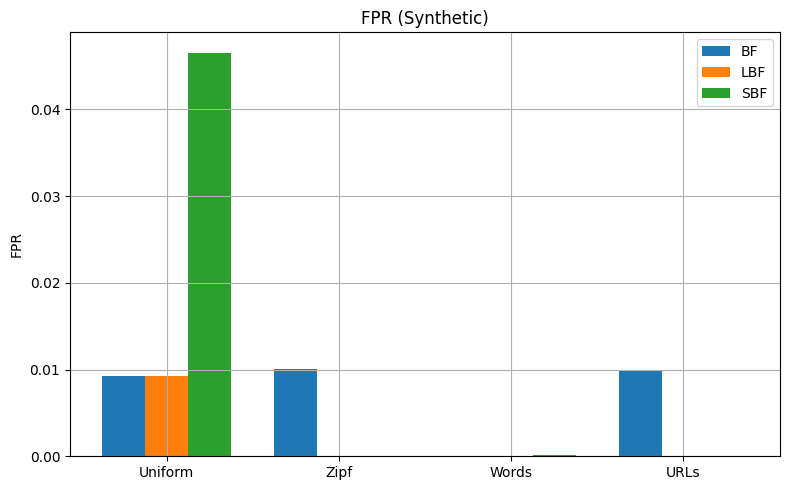

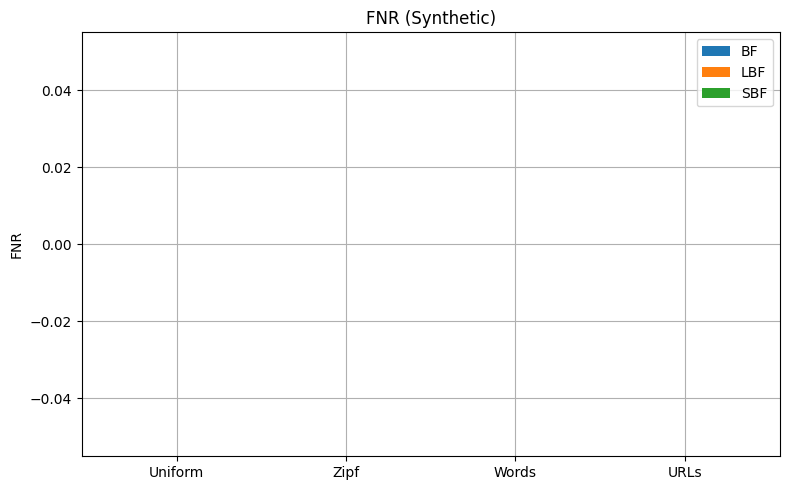

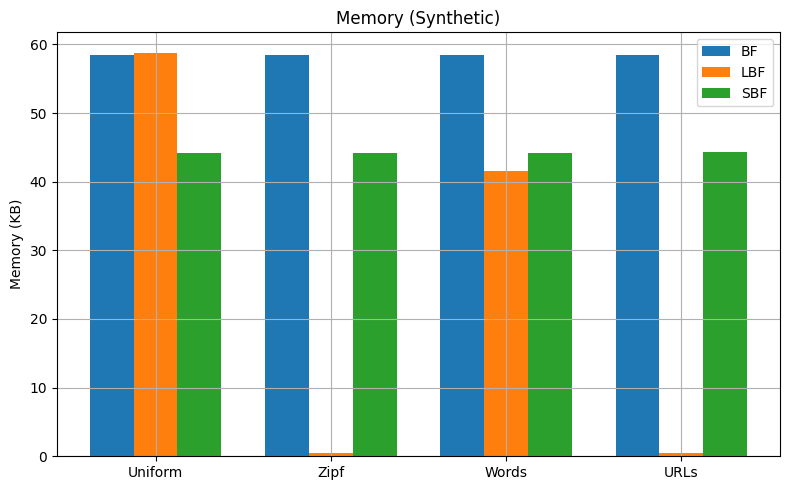

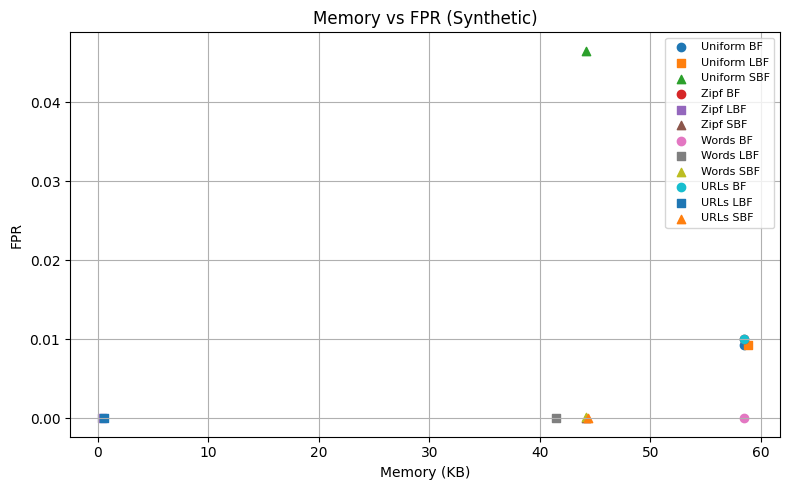

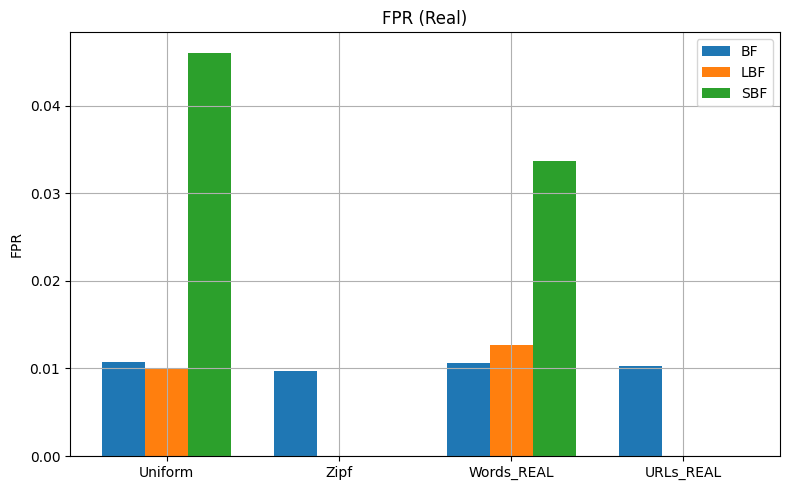

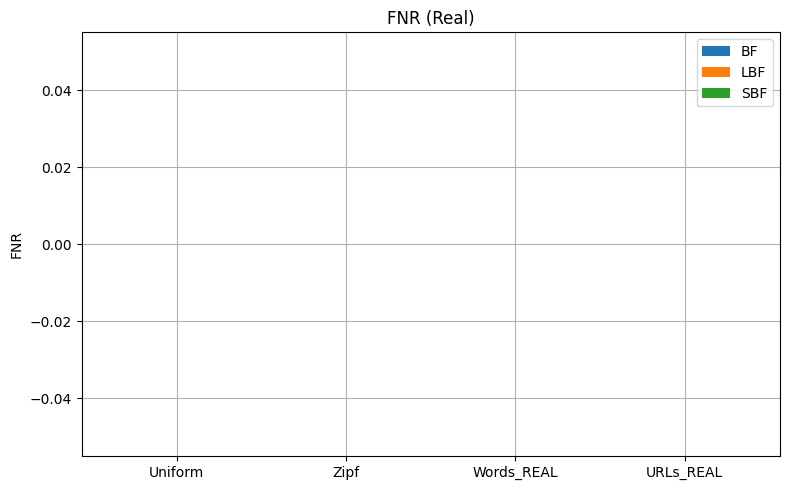

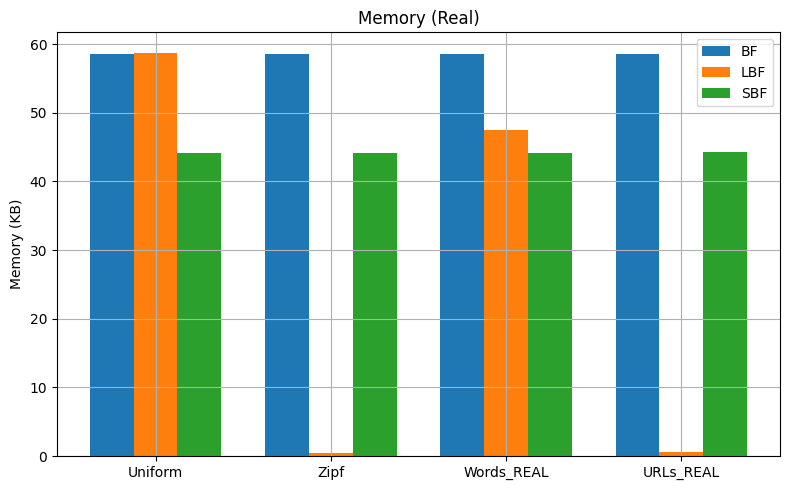

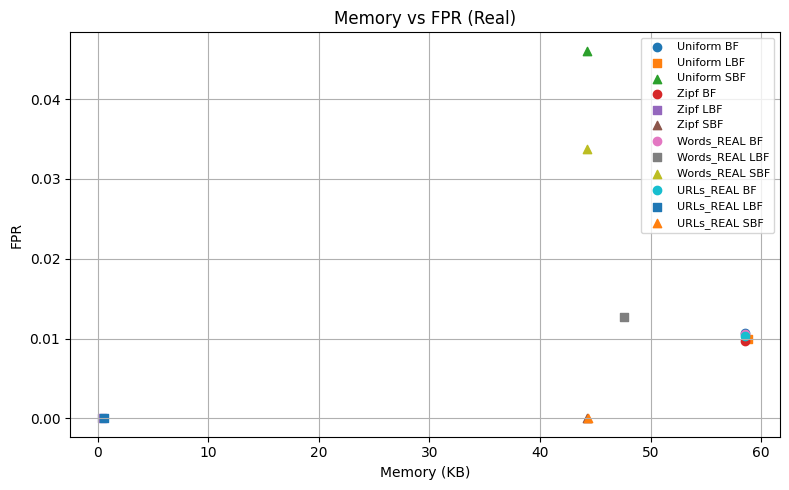

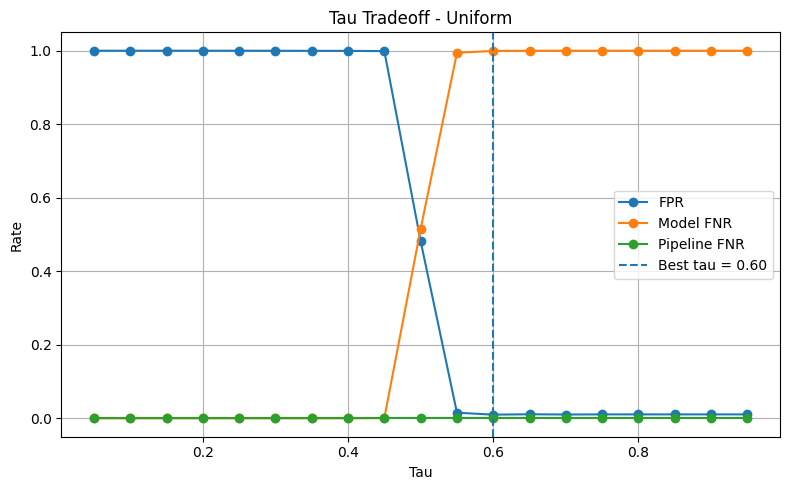

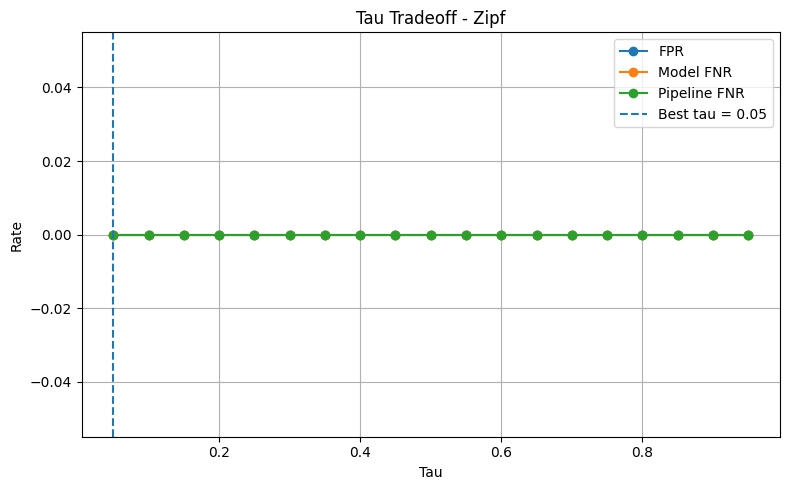

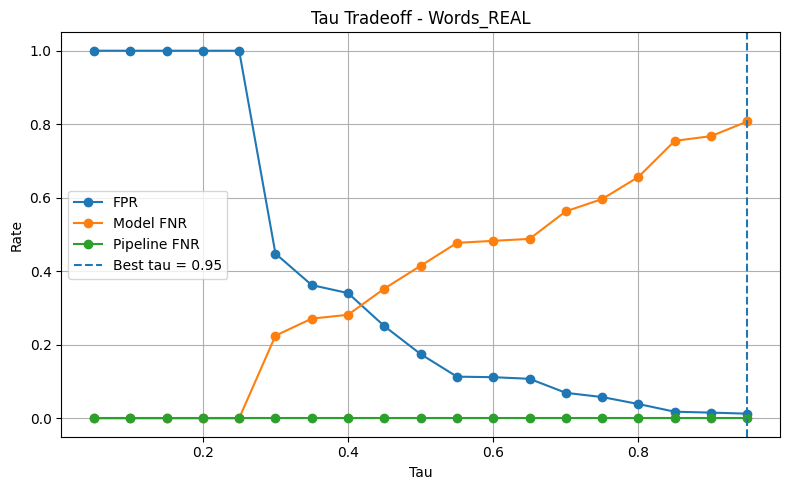

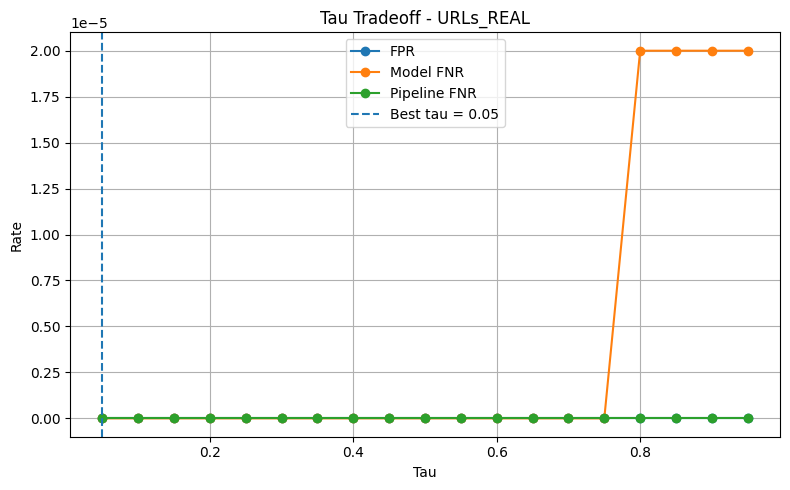

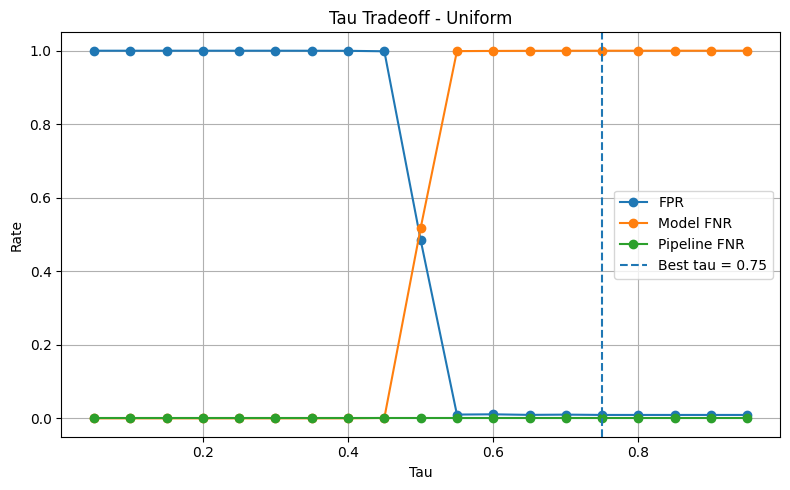

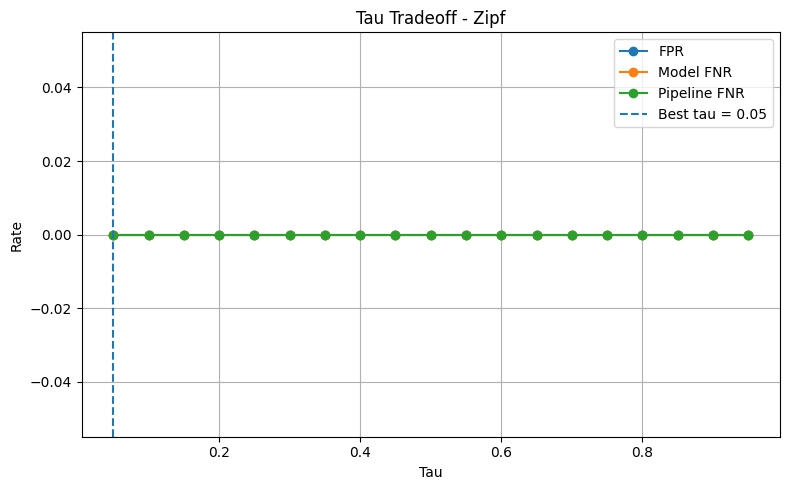

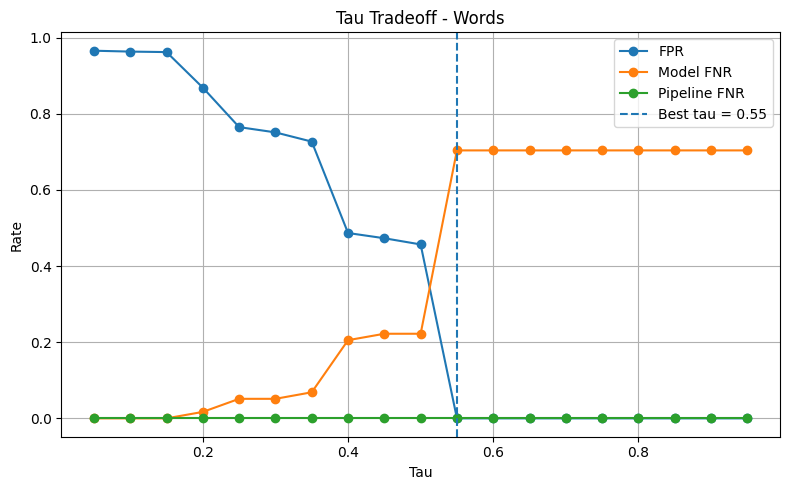

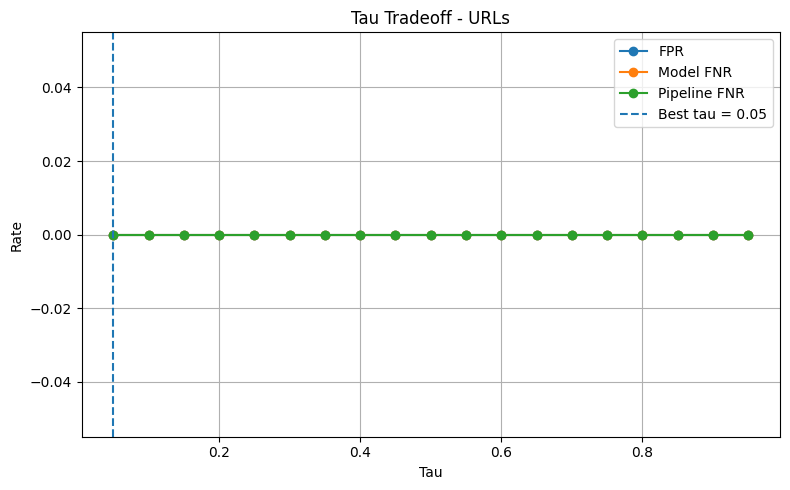

In [21]:
# Synthetic
plot_fpr(results_synthetic, "FPR (Synthetic)")
plot_fnr(results_synthetic, "FNR (Synthetic)")
plot_memory(results_synthetic, "Memory (Synthetic)")
plot_memory_vs_fpr(results_synthetic, "Memory vs FPR (Synthetic)")

# Real
plot_fpr(results_real, "FPR (Real)")
plot_fnr(results_real, "FNR (Real)")
plot_memory(results_real, "Memory (Real)")
plot_memory_vs_fpr(results_real, "Memory vs FPR (Real)")

# Tau curves (VERY IMPORTANT)
for name in results_real:
    plot_tau_curve(results_real, name)

for name in results_synthetic:
    plot_tau_curve(results_synthetic, name)

Timing Real / Uniform ... BF=1.4µs  LBF=2249.5µs  SBF=143.3µs
Timing Real / Zipf ... BF=1.1µs  LBF=2348.7µs  SBF=111.7µs
Timing Real / Words_REAL ... BF=1.2µs  LBF=2256.7µs  SBF=121.2µs
Timing Real / URLs_REAL ... BF=1.2µs  LBF=2308.9µs  SBF=101.8µs
Timing Synthetic / Uniform ... BF=1.1µs  LBF=2252.0µs  SBF=114.4µs
Timing Synthetic / Zipf ... BF=1.1µs  LBF=2369.1µs  SBF=140.5µs
Timing Synthetic / Words ... BF=1.1µs  LBF=2229.8µs  SBF=1.2µs
Timing Synthetic / URLs ... BF=1.3µs  LBF=2379.1µs  SBF=115.4µs


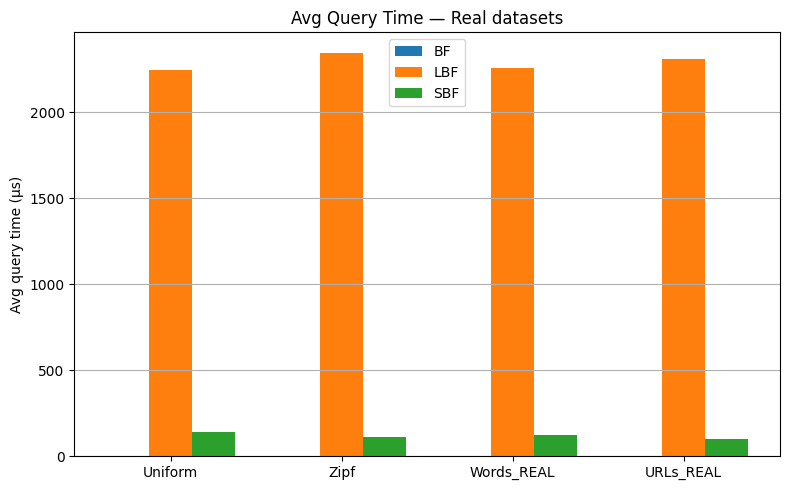

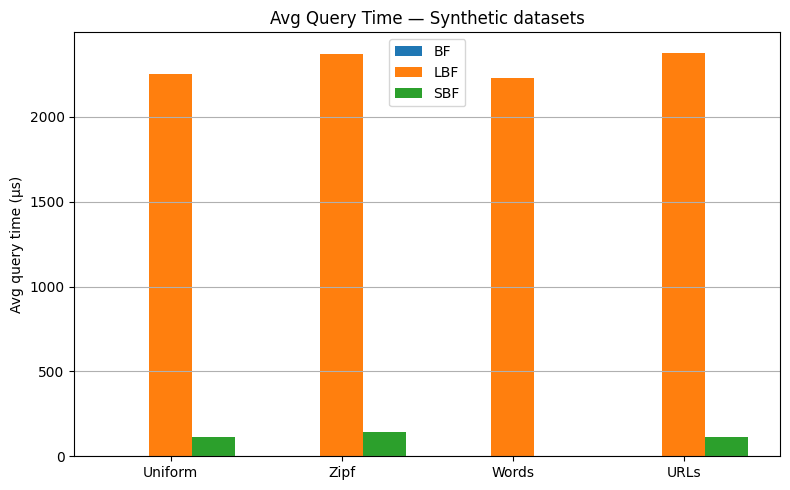

In [22]:
import time
import matplotlib.pyplot as plt
import numpy as np

N_QUERIES = 1000  # queries to time per method
TARGET_FPR = 0.01

def benchmark_query_time(datasets, label):
    """
    For each dataset, rebuild BF / LBF / SBF and time N_QUERIES queries.
    Returns a dict: {dataset_name: {"BF": us, "LBF": us, "SBF": us}}
    """
    timing_results = {}

    for name, (pos, neg) in datasets.items():
        print(f"Timing {label} / {name} ...", end=" ", flush=True)

        feature_fn = get_features_url if "URL" in name.upper() else get_features_word
        n = len(pos)
        queries = neg[:N_QUERIES]   # use negatives so queries are realistic non-members

        # --- Standard BF ---
        bf = BloomFilter(n, TARGET_FPR)
        for k in pos:
            bf.insert(k)
        t0 = time.perf_counter()
        for k in queries:
            bf.query(k)
        bf_us = (time.perf_counter() - t0) / N_QUERIES * 1e6

        # --- Learned BF (use best tau from existing results if available) ---
        model, scaler = train_lbf_model(pos, neg, feature_fn)
        # pick a fixed tau=0.5 for timing (model structure is what matters, not threshold)
        miss = [k for k in pos
                if model.predict_proba(scaler.transform([feature_fn(k)]))[0][1] <= 0.5]
        lbf = LearnedBloomFilter(
            model, scaler, threshold=0.5,
            backup_n=max(len(miss), 100), backup_fpr=TARGET_FPR,
            feature_fn=feature_fn
        )
        for k in pos:
            lbf.insert(k)
        t0 = time.perf_counter()
        for k in queries:
            lbf.query(k)
        lbf_us = (time.perf_counter() - t0) / N_QUERIES * 1e6

        # --- Sandwiched BF ---
        sbf = SandwichedBloomFilter(
            model=model, scaler=scaler, threshold=0.5,
            feature_fn=feature_fn,
            n_pre=n, fpr_pre=0.05,
            n_backup=max(int(n * 0.1), 100), fpr_backup=TARGET_FPR
        )
        for k in pos:
            sbf.insert(k)
        t0 = time.perf_counter()
        for k in queries:
            sbf.query(k)
        sbf_us = (time.perf_counter() - t0) / N_QUERIES * 1e6

        timing_results[name] = {"BF": bf_us, "LBF": lbf_us, "SBF": sbf_us}
        print(f"BF={bf_us:.1f}µs  LBF={lbf_us:.1f}µs  SBF={sbf_us:.1f}µs")

    return timing_results


def plot_query_time(timing_results, title):
    names = list(timing_results.keys())
    bf_t  = [timing_results[n]["BF"]  for n in names]
    lbf_t = [timing_results[n]["LBF"] for n in names]
    sbf_t = [timing_results[n]["SBF"] for n in names]

    x = np.arange(len(names))
    w = 0.25
    plt.figure(figsize=(8, 5))
    plt.bar(x - w, bf_t,  width=w, label="BF")
    plt.bar(x,     lbf_t, width=w, label="LBF")
    plt.bar(x + w, sbf_t, width=w, label="SBF")
    plt.xticks(x, names)
    plt.ylabel("Avg query time (µs)")
    plt.title(title)
    plt.legend()
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()


timing_real      = benchmark_query_time(datasets_real,      "Real")
timing_synthetic = benchmark_query_time(datasets_synthetic, "Synthetic")

plot_query_time(timing_real,      "Avg Query Time — Real datasets")
plot_query_time(timing_synthetic, "Avg Query Time — Synthetic datasets")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import sys

MODEL_CONFIGS = {
    "LogReg": CalibratedClassifierCV(
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        method="isotonic"
    ),
    "RandomForest": CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
        method="isotonic"
    ),
    "MLP": CalibratedClassifierCV(
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
        method="isotonic"
    ),
}


def model_size_bytes(model):
    """Rough byte count of a fitted sklearn estimator via pickle."""
    import pickle
    return len(pickle.dumps(model))


def compare_models(datasets, label, tau=0.5, backup_fpr=0.01, n_neg_eval=5000):
    """For each dataset x model, build an LBF and record FPR + model size."""
    import copy
    all_results = {}   # {dataset: {model_name: {fpr, mem_kb}}}

    for dname, (pos, neg) in datasets.items():
        print(f"\n=== {label} / {dname} ===")
        feature_fn = get_features_url if "URL" in dname.upper() else get_features_word
        n = len(pos)
        neg_eval = neg[:n_neg_eval]

        X = np.array([feature_fn(k) for k in pos + neg])
        y = np.array([1] * n + [0] * len(neg))
        X_train, _, y_train, _ = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)

        dataset_results = {}
        for mname, base_model in MODEL_CONFIGS.items():
            model = copy.deepcopy(base_model)
            model.fit(X_train_sc, y_train)

            # build LBF
            miss = [k for k in pos
                    if model.predict_proba(scaler.transform([feature_fn(k)]))[0][1] <= tau]
            lbf = LearnedBloomFilter(
                model, scaler, threshold=tau,
                backup_n=max(len(miss), 100), backup_fpr=backup_fpr,
                feature_fn=feature_fn
            )
            for k in pos:
                lbf.insert(k)

            fp = sum(1 for k in neg_eval if lbf.query(k))
            fpr = fp / len(neg_eval)
            mem_kb = lbf.memory_bits() / 8 / 1024

            dataset_results[mname] = {"fpr": fpr, "mem_kb": mem_kb}
            print(f"  {mname:15s} -> FPR: {fpr:.4f}  Mem: {mem_kb:.2f} KB")

        all_results[dname] = dataset_results

    return all_results


def plot_model_comparison(all_results, title):
    datasets = list(all_results.keys())
    models   = list(next(iter(all_results.values())).keys())
    x = np.arange(len(datasets))
    w = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, metric in enumerate(["fpr", "mem_kb"]):
        ax = axes[i]
        for j, mname in enumerate(models):
            vals = [all_results[d][mname][metric] for d in datasets]
            ax.bar(x + (j - 1) * w, vals, width=w, label=mname)
        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel("FPR" if metric == "fpr" else "Memory (KB)")
        ax.set_title(f"{title} — {'False Positive Rate' if metric == 'fpr' else 'Memory'}")
        ax.legend()
        ax.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


model_cmp_real      = compare_models(datasets_real,      "Real")
model_cmp_synthetic = compare_models(datasets_synthetic, "Synthetic")

plot_model_comparison(model_cmp_real,      "Model Comparison — Real")
plot_model_comparison(model_cmp_synthetic, "Model Comparison — Synthetic")


=== Real / Uniform ===
  LogReg          -> FPR: 0.4834  Mem: 30.47 KB


In [ ]:
def distribution_shift_experiment(datasets_synthetic, tau=0.5, backup_fpr=0.01, n_neg_eval=5000):
    """
    For every (train_dataset, test_dataset) pair, train LBF on train_dataset
    and evaluate FPR on test_dataset negatives.
    Returns a 2D dict: shift_results[train_name][test_name] = fpr
    """
    names = list(datasets_synthetic.keys())
    shift_results = {n: {} for n in names}

    for train_name in names:
        pos_tr, neg_tr = datasets_synthetic[train_name]
        # all datasets use word features (synthetic datasets are word-like)
        feature_fn = get_features_word
        n = len(pos_tr)

        model, scaler = train_lbf_model(pos_tr, neg_tr, feature_fn)

        miss = [k for k in pos_tr
                if model.predict_proba(scaler.transform([feature_fn(k)]))[0][1] <= tau]
        lbf = LearnedBloomFilter(
            model, scaler, threshold=tau,
            backup_n=max(len(miss), 100), backup_fpr=backup_fpr,
            feature_fn=feature_fn
        )
        for k in pos_tr:
            lbf.insert(k)

        for test_name in names:
            _, neg_te = datasets_synthetic[test_name]
            neg_eval = neg_te[:n_neg_eval]
            fp = sum(1 for k in neg_eval if lbf.query(k))
            fpr = fp / len(neg_eval)
            shift_results[train_name][test_name] = fpr
            marker = " <-- no shift" if train_name == test_name else ""
            print(f"  Train={train_name:10s}  Test={test_name:10s}  FPR={fpr:.4f}{marker}")

    return shift_results


def plot_shift_heatmap(shift_results):
    import matplotlib.colors as mcolors

    names = list(shift_results.keys())
    matrix = np.array([[shift_results[tr][te] for te in names] for tr in names])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="FPR")

    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("Test distribution (negatives)")
    ax.set_ylabel("Train distribution")
    ax.set_title("Distribution Shift — FPR Heatmap\n(diagonal = no shift)")

    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{matrix[i,j]:.3f}",
                    ha="center", va="center", fontsize=10,
                    color="white" if matrix[i,j] > matrix.max() * 0.6 else "black")

    plt.tight_layout()
    plt.show()


print("Distribution Shift Experiment")
shift_results = distribution_shift_experiment(datasets_synthetic)
plot_shift_heatmap(shift_results)

In [ ]:
N_VALUES = [500, 1000, 2500, 5000, 10000, 25000, 50000]
N_QUERIES_SCALE = 500   # queries per timing run (kept small so it's fast)
TARGET_FPR_SCALE = 0.01
TAU_SCALE = 0.5


def scalability_experiment(make_dataset_fn, feature_fn, label):
    """
    Runs BF and LBF at each value of n in N_VALUES.
    Returns list of dicts with keys: n, bf_fpr, lbf_fpr, bf_mem_kb, lbf_mem_kb,
                                       bf_us, lbf_us
    """
    rows = []
    print(f"\nScalability — {label}")
    print(f"{'n':>8}  {'BF FPR':>8}  {'LBF FPR':>8}  {'BF Mem KB':>10}  {'LBF Mem KB':>11}  {'BF µs':>7}  {'LBF µs':>7}")

    for n in N_VALUES:
        pos, neg = make_dataset_fn(n)
        neg_eval  = neg[:min(5000, len(neg))]
        queries   = neg[5000:5000 + N_QUERIES_SCALE]  # separate slice for timing
        if len(queries) < N_QUERIES_SCALE:
            queries = neg[:N_QUERIES_SCALE]

        # --- BF ---
        bf = BloomFilter(n, TARGET_FPR_SCALE)
        for k in pos: bf.insert(k)
        fp_bf = sum(1 for k in neg_eval if bf.query(k))
        bf_fpr = fp_bf / len(neg_eval)
        bf_mem = bf.memory_bits() / 8 / 1024
        t0 = time.perf_counter()
        for k in queries: bf.query(k)
        bf_us = (time.perf_counter() - t0) / N_QUERIES_SCALE * 1e6

        # --- LBF ---
        model, scaler = train_lbf_model(pos, neg, feature_fn)
        miss = [k for k in pos
                if model.predict_proba(scaler.transform([feature_fn(k)]))[0][1] <= TAU_SCALE]
        lbf = LearnedBloomFilter(
            model, scaler, threshold=TAU_SCALE,
            backup_n=max(len(miss), 100), backup_fpr=TARGET_FPR_SCALE,
            feature_fn=feature_fn
        )
        for k in pos: lbf.insert(k)
        fp_lbf = sum(1 for k in neg_eval if lbf.query(k))
        lbf_fpr = fp_lbf / len(neg_eval)
        lbf_mem = lbf.memory_bits() / 8 / 1024
        t0 = time.perf_counter()
        for k in queries: lbf.query(k)
        lbf_us = (time.perf_counter() - t0) / N_QUERIES_SCALE * 1e6

        rows.append(dict(n=n,
                         bf_fpr=bf_fpr,   lbf_fpr=lbf_fpr,
                         bf_mem=bf_mem,   lbf_mem=lbf_mem,
                         bf_us=bf_us,     lbf_us=lbf_us))
        print(f"{n:>8}  {bf_fpr:>8.4f}  {lbf_fpr:>8.4f}  "
              f"{bf_mem:>10.2f}  {lbf_mem:>11.2f}  {bf_us:>7.1f}  {lbf_us:>7.1f}")

    return rows


def plot_scalability(rows, label):
    ns      = [r["n"]      for r in rows]
    bf_fpr  = [r["bf_fpr"] for r in rows]
    lbf_fpr = [r["lbf_fpr"]for r in rows]
    bf_mem  = [r["bf_mem"] for r in rows]
    lbf_mem = [r["lbf_mem"]for r in rows]
    bf_us   = [r["bf_us"]  for r in rows]
    lbf_us  = [r["lbf_us"] for r in rows]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].plot(ns, bf_fpr,  marker="o", label="BF")
    axes[0].plot(ns, lbf_fpr, marker="s", label="LBF")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("n (log scale)")
    axes[0].set_ylabel("FPR")
    axes[0].set_title(f"FPR vs n — {label}")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(ns, bf_mem,  marker="o", label="BF")
    axes[1].plot(ns, lbf_mem, marker="s", label="LBF")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("n (log scale)")
    axes[1].set_ylabel("Memory (KB)")
    axes[1].set_title(f"Memory vs n — {label}")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(ns, bf_us,  marker="o", label="BF")
    axes[2].plot(ns, lbf_us, marker="s", label="LBF")
    axes[2].set_xscale("log")
    axes[2].set_xlabel("n (log scale)")
    axes[2].set_ylabel("Avg query time (µs)")
    axes[2].set_title(f"Query Time vs n — {label}")
    axes[2].legend(); axes[2].grid(True)

    plt.suptitle(f"Scalability Analysis — {label}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


scale_words = scalability_experiment(make_word_dataset, get_features_word, "Words (synthetic)")
plot_scalability(scale_words, "Words (synthetic)")

scale_urls = scalability_experiment(make_url_dataset, get_features_url, "URLs (synthetic)")
plot_scalability(scale_urls, "URLs (synthetic)")